<a href="https://colab.research.google.com/github/nmatsumoto-lgtm/study-KIKAGAKU/blob/main/%E4%B8%8D%E5%8B%95%E7%94%A3%E4%BE%A1%E6%A0%BC%E4%BA%88%E6%B8%AC%E3%82%A2%E3%83%97%E3%83%AA_Ver_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install lightgbm==4.5.0 optuna==3.6.1 joblib pandas numpy scikit-learn

In [ ]:
from __future__ import annotations
import os, re, json, random
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_log_error, r2_score
from joblib import dump
import matplotlib.pyplot as plt

In [ ]:
# ===== 再現性セット=====
import os, random
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
# ================== 入出力パス（5区のみ） ==================
IN_5WARD = Path("/content/drive/MyDrive/project/data/external/train_tabular_5ward.csv")  # ← 5区統合"学習用"テーブル（必須列あり）
ST_GEO   = Path("/content/drive/MyDrive/project/data/external/stations_geo_5ward.csv")   # ← 駅座標（station, ward, lat, lon）
PATH_STATIONS_FEATURES = Path("/content/drive/MyDrive/project/data/external/stations_with_features_5ward.csv")  # 駅の人口/浸水/地価など
IDX_CSV = Path("/content/drive/MyDrive/project/data/external/平均売買㎡単価推移_東京都心5区.csv")  # 相場指数（都心5区）

OUT_DIR = Path("models")
OUT_DIR.mkdir(parents=True, exist_ok=True)

USE_DEFLATE = True  # 相場指数での相対学習を有効化

In [ ]:
MODELS_DIR = Path("/content/drive/MyDrive/project/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MAPS_JSON = MODELS_DIR / "infer_maps.json"

In [ ]:
def save_infer_maps(infer_maps: dict):
    text = json.dumps(infer_maps, ensure_ascii=False, indent=2)
    MAPS_JSON.write_text(text, encoding="utf-8")              # VSCode アプリ用
    (OUT_DIR / "infer_maps.json").write_text(text, encoding="utf-8")  # 保険
    print(f"[OK] infer_maps.json saved → {MAPS_JSON}")

In [ ]:
# ================== 共通ユーティリティ ==================
def _force_unique_cols(df: pd.DataFrame, verbose=True) -> pd.DataFrame:
    cols = list(df.columns)
    if len(cols) == len(set(cols)):
        return df
    from collections import Counter
    cnt = Counter()
    new_cols, dups = [], []
    for c in cols:
        n = cnt[c]
        new_c = c if n == 0 else f"{c}__{n}"
        if n > 0: dups.append((c, new_c))
        new_cols.append(new_c)
        cnt[c] += 1
    if verbose and dups:
        print("[INFO] renamed duplicate columns:", dups[:10], ("... (+more)" if len(dups) > 10 else ""))
    out = df.copy(); out.columns = new_cols
    return out

def _safe_read_csv(p: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(p)
    except UnicodeDecodeError:
        return pd.read_csv(p, encoding="cp932")

In [ ]:
# ================== 相場指数読み込み（重複に強い版） ==================
def _load_avg_psm_monthly(csv_path: Path) -> pd.DataFrame:
    idx = pd.read_csv(csv_path)
    idx = _force_unique_cols(idx)

    cols = {c.lower(): c for c in idx.columns}

    # 価格列の特定（必要ならここに候補を足してください）
    price_col = None
    for k in ["avg_psm_yen", "psm", "price", "単価"]:
        for c in idx.columns:
            if k in c.lower():
                price_col = c; break
        if price_col: break
    if price_col is None:
        raise ValueError("指数CSVに平均㎡単価列（例: avg_psm_yen）が見つかりません。")

    def _to_num(x):
        return pd.to_numeric(str(x).replace(",", "").replace("円", "").replace("¥", "").strip(), errors="coerce")
    idx[price_col] = idx[price_col].map(_to_num)

    # period の用意
    if "period" in cols:
        pcol = cols["period"]
        idx["period"] = pd.to_numeric(idx[pcol], errors="coerce").astype("Int64")
    else:
        ycol, mcol = cols.get("year"), cols.get("month")
        if ycol is None or mcol is None:
            raise ValueError("指数CSVに period か year,month の列が必要です。")
        idx["period"] = (pd.to_numeric(idx[ycol], errors="coerce").astype("Int64")*100
                         + pd.to_numeric(idx[mcol], errors="coerce").astype("Int64"))

    idx = idx.loc[~idx["period"].isna() & ~idx[price_col].isna(), ["period", price_col]].copy()
    idx["period"] = idx["period"].astype(int)

    # 同一 period の重複を平均集約して一意化
    idx = (idx.groupby("period", as_index=False)[price_col]
              .mean()
              .sort_values("period")
              .reset_index(drop=True))

    # 月初の Timestamp → 欠け月を線形補間
    idx["ym"] = pd.to_datetime(idx["period"].astype(str), format="%Y%m")
    idx = idx.set_index("ym").asfreq("MS").interpolate("time").ffill().reset_index()

    idx["period"] = (idx["ym"].dt.year*100 + idx["ym"].dt.month).astype(int)
    idx = idx.rename(columns={price_col: "avg_psm_yen"})
    idx["avg_psm_yen"] = idx["avg_psm_yen"].astype(float)
    idx["log_idx_psm"] = np.log(idx["avg_psm_yen"])
    idx["idx_mom"] = idx["avg_psm_yen"].pct_change().fillna(0.0)
    idx["idx_yoy"] = idx["avg_psm_yen"].pct_change(12).fillna(0.0)
    return idx[["period","avg_psm_yen","log_idx_psm","idx_mom","idx_yoy"]]

def compute_calibration(period_arr, idx_csv: Path, smooth_months: int = 2) -> float:
    try:
        idx = _load_avg_psm_monthly(idx_csv).sort_values("period")
        last_train = int(np.max(period_arr))
        p_train = idx.loc[idx["period"] <= last_train, "avg_psm_yen"]
        if len(p_train) == 0: return 1.0
        base = float(p_train.tail(smooth_months).mean())
        latest = float(idx["avg_psm_yen"].tail(smooth_months).mean())
        return latest/base if base>0 else 1.0
    except Exception:
        return 1.0

In [ ]:
# ================== 駅特徴の前処理 ==================
def _normalize_station_name(s: str) -> str:
    if not isinstance(s, str): return ""
    return (s.replace("（","(").replace("）",")").replace("　"," ").strip())

def _prepare_station_features() -> pd.DataFrame:
    assert PATH_STATIONS_FEATURES.exists(), f"Not found: {PATH_STATIONS_FEATURES}"
    sf = _safe_read_csv(PATH_STATIONS_FEATURES).copy()
    # 駅名列
    name_col = None
    for c in sf.columns:
        lc = c.lower()
        if lc in ("station_name","station") or "駅" in c:
            name_col = c; break
    if name_col is None:
        raise ValueError("stations_with_features に駅名列が必要です。")

    sf = sf.rename(columns={name_col: "station"})
    sf["station"] = sf["station"].astype(str).map(_normalize_station_name)

    # 列名標準化
    sf = sf.rename(columns={
        "pop_sum":"st_pop_sum",
        "pop_min":"st_pop_min",
        "flood_ratio":"st_flood_ratio",
        "flood_flag":"st_flood_flag",
    })
    keep = ["station","st_pop_sum","st_pop_min","st_flood_ratio","st_flood_flag","land25_mean","land_yoy_rate","land_logdiff"]
    exist = [c for c in keep if c in sf.columns]
    sf = sf[exist].copy()

    for c in sf.columns:
        if c=="station": continue
        if sf[c].dropna().isin([0,1,True,False]).all():
            sf[c] = sf[c].astype(int)
        else:
            sf[c] = pd.to_numeric(sf[c], errors="coerce").fillna(0)
    return sf

def _merge_station_features(df: pd.DataFrame) -> pd.DataFrame:
    df2 = df.copy()
    df2["station"] = df2["station"].astype(str).map(_normalize_station_name)
    stf = _prepare_station_features()
    merged = df2.merge(stf, how="left", on="station")
    for c in merged.columns:
        if c!="station" and merged[c].dtype.kind in "fi":
            merged[c] = merged[c].fillna(0.0)
    return _force_unique_cols(merged)

In [ ]:
# ================== エリア（グループ）付与 ==================
# 中央区：固定
STATION_TO_AREA_CHUO = {
    "銀座":"銀座・京橋","東銀座":"銀座・京橋","銀座一丁目":"銀座・京橋","京橋(東京)":"銀座・京橋",
    "宝町(東京)":"銀座・京橋","新橋":"銀座・京橋","汐留":"銀座・京橋","東京":"銀座・京橋",
    "日本橋(東京)":"日本橋・人形町","三越前":"日本橋・人形町","新日本橋":"日本橋・人形町",
    "茅場町":"日本橋・人形町","人形町":"日本橋・人形町","水天宮前":"日本橋・人形町",
    "浜町":"日本橋・人形町","東日本橋":"日本橋・人形町","小伝馬町":"日本橋・人形町",
    "馬喰横山":"日本橋・人形町","馬喰町":"日本橋・人形町",
    "月島":"月島・勝どき・晴海","勝どき":"月島・勝どき・晴海",
    "築地":"築地・八丁堀","築地市場":"築地・八丁堀","新富町(東京)":"築地・八丁堀","八丁堀(東京)":"築地・八丁堀",
}
AREA_LIST_CHUO = ["銀座・京橋","日本橋・人形町","月島・勝どき・晴海","築地・八丁堀","佃・新川・湊","その他"]

# 他4区：シード最近傍
SEEDS = {
    "新宿区": {
        "G1_新宿周辺":["新宿","新大久保","西新宿","西武新宿","都庁前","初台"],
        "G2_東寄り":["神楽坂","飯田橋","江戸川橋","牛込柳町"],
        "G3_西北部":["高田馬場","落合","中井","下落合","面影橋"],
        "G4_東南部":["四ツ谷","信濃町","曙橋","若松河田"],
        "G5_東中野周辺":["東中野","西早稲田","中野坂上"],
    },
    "渋谷区": {
        "G1_南東部":["渋谷","代官山","恵比寿","広尾"],
        "G2_北東部":["代々木","原宿","千駄ヶ谷","北参道"],
        "G3_北西部":["幡ヶ谷","笹塚","初台"],
        "G4_西部":["代々木上原","代々木八幡","代々木公園","神泉"],
    },
    "港区": {
        "G1_六本木周辺":["六本木","乃木坂","六本木一丁目"],
        "G2_北部オフィス":["新橋","浜松町","御成門","汐留"],
        "G3_青山エリア":["表参道","外苑前","青山一丁目"],
        "G4_東部":["田町","三田","赤羽橋"],
        "G5_臨海":["台場","お台場海浜公園","芝浦ふ頭"],
    },
    "千代田区": {
        "G1_丸の内皇居":["大手町","東京","二重橋前","日比谷"],
        "G2_北東部":["秋葉原","神田","御茶ノ水","淡路町"],
        "G3_西部":["市ケ谷","九段下","半蔵門","麹町"],
        "G4_東部":["小伝馬町","人形町","岩本町","竹橋"],
    },
}

def _haversine(lat1, lon1, lat2, lon2):
    R = 6371000.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dlat = p2 - p1
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def _build_seed_lookup(st_geo: pd.DataFrame) -> dict[tuple[str,str], str]:
    lut: dict[tuple[str,str], str] = {}

    # 列名を標準化（Ward/Lon/Lng の表記揺れ吸収）
    lower = {c.lower(): c for c in st_geo.columns}
    st_geo = st_geo.rename(columns={
        lower.get("ward","ward"): "ward",
        lower.get("station","station"): "station",
        lower.get("lat","lat"): "lat",
        lower.get("lon", lower.get("lng","lon")): "lon",
    })

    # 中央区：固定マップ
    chuo = st_geo[st_geo["ward"]=="中央区"].copy()
    chuo["station_n"] = chuo["station"].astype(str).map(_normalize_station_name)
    for _, row in chuo.iterrows():
        lut[("中央区", row["station_n"])] = STATION_TO_AREA_CHUO.get(row["station_n"], "その他")

    # 他4区：最近傍シード割当
    for ward, groups in SEEDS.items():
        ward_geo = st_geo[st_geo["ward"]==ward].copy()
        if ward_geo.empty: continue
        ward_geo["station_n"] = ward_geo["station"].astype(str).map(_normalize_station_name)

        seed_rows = []
        for area_name, seed_stations in groups.items():
            for seed in seed_stations:
                seed_n = _normalize_station_name(seed)
                hit = ward_geo[ward_geo["station_n"] == seed_n]
                if not hit.empty:
                    seed_rows.append({"area": area_name, "station_n": seed_n,
                                      "lat": hit.iloc[0]["lat"], "lon": hit.iloc[0]["lon"]})
        if not seed_rows:
            for _, row in ward_geo.iterrows():
                lut[(ward, row["station_n"])] = "その他"
            continue

        seeds_df = pd.DataFrame(seed_rows)
        for _, row in ward_geo.iterrows():
            lat, lon = row["lat"], row["lon"]
            if pd.isna(lat) or pd.isna(lon):
                lut[(ward, row["station_n"])] = list(groups.keys())[0]
                continue
            dists = _haversine(lat, lon, seeds_df["lat"].values, seeds_df["lon"].values)
            idx = int(np.argmin(dists))
            lut[(ward, row["station_n"])] = seeds_df.iloc[idx]["area"]
    return lut

def station_to_area(ward: str, station: str, lut: dict[tuple[str,str], str]) -> str:
    return lut.get((str(ward), _normalize_station_name(station)), "その他")

In [ ]:
# ================== OOFターゲット統計 ==================
def _oof_target_median(df: pd.DataFrame, key: str, y: np.ndarray, n_splits: int = 5) -> np.ndarray:
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    oof = np.zeros(len(df), dtype=float)
    for tr, va in kf.split(df):
        med = pd.DataFrame({key: df.iloc[tr][key].values, "y": y[tr]}).groupby(key)["y"].median()
        oof[va] = df.iloc[va][key].map(med).fillna(med.median()).values
    return oof

def _oof_target_mean(df, key, y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    oof = np.zeros(len(df), dtype=float)
    for tr, va in kf.split(df):
        m = pd.DataFrame({key: df.iloc[tr][key].values, "y": y[tr]}).groupby(key)["y"].mean()
        oof[va] = df.iloc[va][key].map(m).fillna(m.mean()).values
    return oof


In [ ]:
# ================== 5) テーブル構築（読むだけ＋環境＋グループ） ==================
def build_table_and_features():
    # 1) infer_maps を先頭で初期化（既存があれば読み込む）
    infer_maps = {}
    if MAPS_JSON.exists():
        try:
            infer_maps = json.loads(MAPS_JSON.read_text(encoding="utf-8"))
        except Exception:
            infer_maps = {}

    # 2) 学習テーブル読込 & 必須列チェック
    assert IN_5WARD.exists(), f"Not found: {IN_5WARD}"
    df = _safe_read_csv(IN_5WARD)
    df = _force_unique_cols(df)

    need = {"ward","station","year","month","period","walk_min","築年数","area_sqm","price_yen","layout"}
    miss = sorted(list(need - set(df.columns)))
    if miss:
        raise ValueError(f"train_tabular_5ward.csv の必須列が不足: {miss}")

    # 3) 駅環境特徴のマージ（人口/浸水/地価など）
    df = _merge_station_features(df)

    # 4) 外部指数をJOIN（deflate用）
    idx = _load_avg_psm_monthly(IDX_CSV)
    df = df.merge(idx, on="period", how="left")
    for c in ["avg_psm_yen","log_idx_psm","idx_mom","idx_yoy"]:
        df[c] = df[c].ffill().bfill()

    # 5) エリア（グループ）付与
    assert ST_GEO.exists(), f"Not found: {ST_GEO}"
    st_geo = _safe_read_csv(ST_GEO)
    st_geo = _force_unique_cols(st_geo)
    lut = _build_seed_lookup(st_geo)  # （中央区は固定マップ、他4区は最近傍シード）
    df["area_group"] = [station_to_area(w, s, lut) for w, s in zip(df["ward"], df["station"])]

    # 6) 目的変数（deflate対応）
    y_yen = pd.to_numeric(df["price_yen"], errors="coerce").astype(float).values
    y_log_true = np.log1p(y_yen)
    if USE_DEFLATE:
        y_log = np.log1p(y_yen) - np.log(df["avg_psm_yen"].astype(float).values)
    else:
        y_log = y_log_true.copy()

    # 7) 基本/派生特徴
    df["walk_min"]  = pd.to_numeric(df["walk_min"], errors="coerce")
    df["築年数"]      = pd.to_numeric(df["築年数"], errors="coerce")
    df["area_sqm"]  = pd.to_numeric(df["area_sqm"], errors="coerce")

    df["access_score"]   = 1.0/(1.0 + df["walk_min"])
    df["sqrt_area"]      = np.sqrt(np.clip(df["area_sqm"], 0, None))
    df["log_area"]       = np.log1p(np.clip(df["area_sqm"], 0, None))
    df["age_sqrt"]       = np.sqrt(np.clip(df["築年数"], 0, None))
    df["area_x_access"]  = df["area_sqm"] * df["access_score"]

    # 8) 頻度特徴
    st_cnt = df["station"].value_counts()
    ly_cnt = df["layout"].value_counts()
    ag_cnt = df["area_group"].value_counts()
    df["station_count"] = df["station"].map(st_cnt).fillna(0).astype(int)
    df["layout_count"]  = df["layout"].map(ly_cnt).fillna(0).astype(int)
    df["area_count"]    = df["area_group"].map(ag_cnt).fillna(0).astype(int)

    # 9) OOFターゲット統計（リーク防止）
    df["station_oof_median_log"] = _oof_target_median(df, "station",    y_log)
    df["layout_oof_median_log"]  = _oof_target_median(df, "layout",     y_log)
    df["area_oof_median_log"]    = _oof_target_median(df, "area_group", y_log)
    df["station_oof_mean_log"]   = _oof_target_mean  (df, "station",    y_log)
    df["layout_oof_mean_log"]    = _oof_target_mean  (df, "layout",     y_log)
    df["area_oof_mean_log"]      = _oof_target_mean  (df, "area_group", y_log)

    # 10) 推論用の統計マップ（駅/間取り/エリアの中央値・平均）
    station_med_map = df.groupby("station")["station_oof_median_log"].median().to_dict()
    layout_med_map  = df.groupby("layout") ["layout_oof_median_log"].median().to_dict()
    area_med_map    = df.groupby("area_group")["area_oof_median_log"].median().to_dict()
    station_mean_map= df.groupby("station")["station_oof_mean_log"].mean().to_dict()
    layout_mean_map = df.groupby("layout") ["layout_oof_mean_log"].mean().to_dict()
    area_mean_map   = df.groupby("area_group")["area_oof_mean_log"].mean().to_dict()

    global_station_med = float(np.median(list(station_med_map.values()))) if station_med_map else float(np.median(y_log))
    global_layout_med  = float(np.median(list(layout_med_map.values())))  if layout_med_map  else float(np.median(y_log))
    global_area_med    = float(np.median(list(area_med_map.values())))    if area_med_map    else float(np.median(y_log))
    global_station_mean= float(np.mean(list(station_mean_map.values())))  if station_mean_map else float(np.mean(y_log))
    global_layout_mean = float(np.mean(list(layout_mean_map.values())))   if layout_mean_map  else float(np.mean(y_log))
    global_area_mean   = float(np.mean(list(area_mean_map.values())))     if area_mean_map    else float(np.mean(y_log))

    # 11) 列セット
    feat_cat = ["ward","area_group","station","layout"]
    feat_num_base = ["walk_min","築年数","area_sqm"]
    feat_num_extra = [
        "access_score","sqrt_area","log_area","age_sqrt","area_x_access",
        "station_count","layout_count","area_count",
        "station_oof_median_log","layout_oof_median_log","area_oof_median_log",
        "station_oof_mean_log","layout_oof_mean_log","area_oof_mean_log",
        "log_idx_psm","idx_mom","idx_yoy",
        "st_pop_sum","st_pop_min","st_flood_ratio",
        "land25_mean","land_yoy_rate","land_logdiff",
    ]
    feat_num_all = feat_num_base + feat_num_extra

    # 12) 単調制約（LightGBM）
    mono_dict = {name: 0 for name in feat_num_all}
    mono_dict.update({
        "walk_min": -1, "築年数": -1,
        "area_sqm": +1, "access_score": +1,
        "sqrt_area": +1, "log_area": +1,
        "age_sqrt": -1
    })
    monotone_constraints = [0]*len(feat_cat) + [mono_dict[c] for c in feat_num_all]

    # 13) 直近重み
    year_s  = pd.to_numeric(df["year"],  errors="coerce").astype(int)
    month_s = pd.to_numeric(df["month"], errors="coerce").astype(int)
    latest_m = int(year_s.max())*12 + int(month_s.max())
    months_old = (latest_m - (year_s*12 + month_s)).clip(lower=0)
    w = np.power(0.5, months_old/12.0)
    w = np.clip(w, 0.2, None)
    sample_weight = w.values.astype(float)

    # 14) カテゴリエンコード
    oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_cat = oe.fit_transform(df[feat_cat].fillna("NA")).astype("int32")
    cat_cols = [f"cat__{c}" for c in feat_cat]

    # 15) 数値結合 → DataFrame化（重複名ガード）
    X_num = df[feat_num_all].astype(float).values
    X = np.hstack([X_cat, X_num])
    col_list = cat_cols + feat_num_all
    if len(col_list) != len(set(col_list)):
        from collections import Counter
        cnt = Counter(col_list)
        seen = {}
        col_list = [c if seen.get(c,0)==0 else f"{c}__{seen[c]}" for c in (seen.update({c:seen.get(c,0)+1}) or col_list) ]  # 保険
    X_df = pd.DataFrame(X, columns=col_list)

    # 16) 推論用マップ（区×駅 → エリア、学習最終期など）
    station_norm = df["station"].astype(str).map(_normalize_station_name)
    key_series = df["ward"].astype(str) + "||" + station_norm
    ward_station_to_area_map = pd.Series(df["area_group"].values, index=key_series).to_dict()

    last_train_period = int(df["period"].max())
    last_train_period_by_ward = df.groupby("ward")["period"].max().astype(int).to_dict()
    station_to_area_map_chuo = STATION_TO_AREA_CHUO  # 保険

    # 17) infer_maps を更新（「追記」だけ。上書き代入しない）
    infer_maps.update({
        "station_count_map": st_cnt.to_dict(),
        "layout_count_map":  ly_cnt.to_dict(),
        "area_count_map":    ag_cnt.to_dict(),
        "station_median_log_map": station_med_map,
        "layout_median_log_map":  layout_med_map,
        "area_median_log_map":    area_med_map,
        "station_mean_log_map":   station_mean_map,
        "layout_mean_log_map":    layout_mean_map,
        "area_mean_log_map":      area_mean_map,
        "global_station_median_log": global_station_med,
        "global_layout_median_log":  global_layout_med,
        "global_area_median_log":    global_area_med,
        "global_station_mean_log":   global_station_mean,
        "global_layout_mean_log":    global_layout_mean,
        "global_area_mean_log":      global_area_mean,
        "area_groups_chuo": AREA_LIST_CHUO,
        "station_to_area_map": station_to_area_map_chuo,  # 互換のため追加
        "area_groups": AREA_LIST_CHUO,                    # 互換のため追加
        "seeds_4wards": SEEDS,
        "feat_cat": feat_cat,
        "feat_num": feat_num_all,
        "ward_station_to_area_map": ward_station_to_area_map,
        "last_train_period": last_train_period,
        "last_train_period_by_ward": last_train_period_by_ward,
        "station_to_area_map_chuo": station_to_area_map_chuo,
        "cat_cols": cat_cols,
        "oe_categories_": [list(c) for c in oe.categories_],
        "meta": {
            "n_rows": int(len(X_df)),
            "n_features": int(X_df.shape[1]),
            "wards": sorted(pd.unique(df["ward"]).tolist()),
        },
    })

    # 18) infer_maps を保存（保存先は MAPS_JSON に統一）
    try:
        MAPS_JSON.write_text(json.dumps(infer_maps, ensure_ascii=False, indent=2), encoding="utf-8")
    except Exception as e:
        print(f"[WARN] infer_maps.json の保存に失敗: {e}")

    # 19) 返却（呼び出し側が待っている12要素の順序で）
    avg_psm_arr = df["avg_psm_yen"].to_numpy()
    period_arr  = df["period"].to_numpy().astype(int)
    ward_arr    = df["ward"].astype(str).to_numpy()
    meta = {
        "feat_cat": feat_cat,
        "feat_num": feat_num_all,
        "categorical_feature": cat_cols,
        "monotone_constraints": [0]*len(feat_cat) + [mono_dict[c] for c in feat_num_all],
    }
    return (X_df, y_log, cat_cols, meta["monotone_constraints"],
            meta, oe, infer_maps, sample_weight, avg_psm_arr, y_log_true, period_arr, ward_arr)


In [ ]:
# ================== ハイパラ探索（時系列CV） ==================
def tune_with_optuna(
    X_df, y_log, y_log_true, categorical_feature, monotone_constraints,
    period_arr, n_trials=200, sample_weight=None, avg_psm=None
) -> tuple[dict, int, float]:

    order = np.argsort(period_arr)
    X_ord = X_df.iloc[order]; y_ord = y_log[order]; y_true_ord = y_log_true[order]
    w_ord = None if sample_weight is None else sample_weight[order]
    avg_ord = None if avg_psm is None else avg_psm[order]

    tscv = TimeSeriesSplit(n_splits=5)

    def objective(trial: optuna.Trial) -> float:
        params = {
            "objective": "rmse", "metric": "rmse",
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 31, 255),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 200),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 0, 10),
            "min_gain_to_split": trial.suggest_float("min_gain_to_split", 0.0, 5.0),
            "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
            "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
            "verbosity": -1, "seed": SEED,
            "monotone_constraints": monotone_constraints,
        }

        rmsles, best_iters = [], []
        for tr_rel, va_rel in tscv.split(X_ord):
            X_tr, X_va = X_ord.iloc[tr_rel], X_ord.iloc[va_rel]
            y_tr, y_va = y_ord[tr_rel], y_ord[va_rel]
            w_tr = None if w_ord is None else w_ord[tr_rel]
            w_va = None if w_ord is None else w_ord[va_rel]

            dtr = lgb.Dataset(X_tr, label=y_tr, weight=w_tr,
                              categorical_feature=categorical_feature, free_raw_data=True)
            dva = lgb.Dataset(X_va, label=y_va, weight=w_va,
                              categorical_feature=categorical_feature, free_raw_data=True)

            model = lgb.train(params, dtr, valid_sets=[dva],
                              num_boost_round=4000,
                              callbacks=[lgb.early_stopping(200, verbose=False)])
            pred_log = model.predict(X_va, num_iteration=model.best_iteration)

            if USE_DEFLATE and (avg_ord is not None):
                yhat_yen  = np.expm1(pred_log + np.log(avg_ord[va_rel]))
                ytrue_yen = np.expm1(y_true_ord[va_rel])
                rmsle = float(np.sqrt(mean_squared_log_error(ytrue_yen, yhat_yen)))
            else:
                rmsle = float(np.sqrt(mean_squared_log_error(np.expm1(y_va), np.expm1(pred_log))))
            rmsles.append(rmsle)
            best_iters.append(model.best_iteration)

        trial.set_user_attr("best_iters", best_iters)
        return float(np.mean(rmsles))

    study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params
    best_round = int(np.clip(np.mean(study.best_trial.user_attrs.get("best_iters", [1000])), 100, 4000))
    best_score = study.best_value
    return best_params, best_round, best_score

In [ ]:
# ================== 最終学習（ポイント & 分位点） ==================
def train_final_models(
    X_df: pd.DataFrame, y_log: np.ndarray, categorical_feature: list[str],
    monotone_constraints: list[int], best_params: dict, best_round: int,
    sample_weight: np.ndarray | None = None
):
    base_params = dict(best_params)
    base_params.update({"objective":"rmse","metric":"rmse","verbosity":-1,"seed":SEED,
                        "monotone_constraints": monotone_constraints})
    dtrain = lgb.Dataset(X_df, label=y_log, weight=sample_weight,
                         categorical_feature=categorical_feature, free_raw_data=False)
    model_point = lgb.train(base_params, dtrain, num_boost_round=best_round)

    pred_log_tr = model_point.predict(X_df, num_iteration=getattr(model_point,"best_iteration",None))
    resid = y_log - pred_log_tr
    smearing = (float(np.average(np.exp(resid), weights=sample_weight))
                if sample_weight is not None else float(np.mean(np.exp(resid))))

    models_q = {}
    for alpha, tag in [(0.1,"q10"), (0.9,"q90")]:
        q_params = dict(best_params)
        q_params.update({"objective":"quantile","alpha":alpha,"metric":"quantile","verbosity":-1,"seed":SEED})
        models_q[tag] = lgb.train(q_params, dtrain, num_boost_round=best_round)
    return model_point, models_q, smearing

In [ ]:
# ================== 実行（5区のみ） ==================
if __name__ == "__main__":
    assert IN_5WARD.exists(), f"Not found: {IN_5WARD}"

    X_df, y_log, cat_cols, mono_cons, meta, oe, infer_maps, sample_weight, avg_psm_arr, y_log_true, period_arr, ward_arr = build_table_and_features()
    print(f"Train rows: {len(X_df):,}, cols: {X_df.shape[1]} (cats={len(cat_cols)})")
    save_infer_maps(infer_maps)

    best_params, best_round, best_score = tune_with_optuna(
        X_df, y_log, y_log_true, cat_cols, mono_cons, period_arr,
        n_trials=200, sample_weight=sample_weight, avg_psm=avg_psm_arr
    )
    print("[OPTUNA] best RMSLE:", round(best_score, 4))
    print("[OPTUNA] best params:")
    for k, v in best_params.items():
        print(f"  {k}: {v}")
    print("[OPTUNA] best_round:", best_round)

    model_point, models_q, smearing = train_final_models(
        X_df, y_log, cat_cols, mono_cons, best_params, best_round, sample_weight=sample_weight
    )

    calib = compute_calibration(period_arr, IDX_CSV, smooth_months=2)
    print(f"[CALIB] multiplier to latest: {calib:.4f}")

[I 2025-09-23 11:37:33,235] A new study created in memory with name: no-name-5ba0d99f-1ab5-40d2-8d1d-c60df5102ef4


Train rows: 9,787, cols: 30 (cats=4)
[OK] infer_maps.json saved → /content/drive/MyDrive/project/models/infer_maps.json


[I 2025-09-23 11:37:44,611] Trial 0 finished with value: 0.2838439325487401 and parameters: {'learning_rate': 0.030710573677773714, 'num_leaves': 244, 'min_data_in_leaf': 149, 'feature_fraction': 0.8394633936788146, 'bagging_fraction': 0.6624074561769746, 'bagging_freq': 1, 'min_gain_to_split': 0.2904180608409973, 'lambda_l1': 0.6245760287469893, 'lambda_l2': 0.002570603566117598}. Best is trial 0 with value: 0.2838439325487401.
[I 2025-09-23 11:37:48,612] Trial 1 finished with value: 0.30242963145268026 and parameters: {'learning_rate': 0.08341106432362087, 'num_leaves': 35, 'min_data_in_leaf': 195, 'feature_fraction': 0.9329770563201687, 'bagging_fraction': 0.6849356442713105, 'bagging_freq': 2, 'min_gain_to_split': 0.9170225492671691, 'lambda_l1': 5.472429642032198e-06, 'lambda_l2': 0.00052821153945323}. Best is trial 0 with value: 0.2838439325487401.
[I 2025-09-23 11:37:52,702] Trial 2 finished with value: 0.3078060205556481 and parameters: {'learning_rate': 0.03647316284911211, 'n

[OPTUNA] best RMSLE: 0.2552
[OPTUNA] best params:
  learning_rate: 0.015431857221609105
  num_leaves: 200
  min_data_in_leaf: 18
  feature_fraction: 0.851571100551814
  bagging_fraction: 0.8149413359383219
  bagging_freq: 8
  min_gain_to_split: 0.007549861494612259
  lambda_l1: 3.3542495560449506e-07
  lambda_l2: 0.0001414870430571258
[OPTUNA] best_round: 586
[CALIB] multiplier to latest: 1.1480


In [ ]:
# ===== 学習＆OOF精度（円スケールで表示）=====
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import lightgbm as lgb
import numpy as np

def _fmt_metric_row(tag, rmsle, r2, rmse_y, mae_y, mape):
    print(f"[{tag}] RMSLE={rmsle:.4f} | R2(log)={r2:.4f} | RMSE(円)={rmse_y:,.0f} | MAE(円)={mae_y:,.0f} | MAPE={mape:.2f}%")

def _yen_metrics(y_true_yen: np.ndarray, y_pred_yen: np.ndarray):
    rmse_y = float(np.sqrt(np.mean((y_true_yen - y_pred_yen) ** 2)))
    mae_y  = float(np.mean(np.abs(y_true_yen - y_pred_yen)))
    mape   = float(np.mean(np.abs((y_true_yen - y_pred_yen) / np.clip(y_true_yen, 1.0, None))) * 100.0)
    return rmse_y, mae_y, mape

# --- 学習データ上の精度 ---
best_it = getattr(model_point, "best_iteration", None)
y_log_pred_tr = model_point.predict(X_df, num_iteration=best_it)

# log空間の指標（deflate前のRMSLE相当）
rmsle_tr = float(np.sqrt(np.mean((y_log - y_log_pred_tr) ** 2)))
r2_tr    = float(r2_score(y_log, y_log_pred_tr))

# 真値は log1p から円へ戻す
y_true_yen = np.expm1(y_log_true)

# smear 安全化
try:
    smear = float(smearing)
except NameError:
    smear = 1.0

# 円スケール予測（deflate 対応）
if USE_DEFLATE and (avg_psm_arr is not None):
    y_pred_yen_tr = smear * np.expm1(y_log_pred_tr + np.log(avg_psm_arr))
else:
    y_pred_yen_tr = smear * np.expm1(y_log_pred_tr)

rmse_y_tr, mae_y_tr, mape_tr = _yen_metrics(y_true_yen, y_pred_yen_tr)
_fmt_metric_row("TRAIN", rmsle_tr, r2_tr, rmse_y_tr, mae_y_tr, mape_tr)

# --- KFold OOF（疑似バリデーション）---
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
oof_pred_log = np.zeros_like(y_log, dtype=float)

for tr_idx, va_idx in kf.split(X_df):
    X_tr, X_va = X_df.iloc[tr_idx], X_df.iloc[va_idx]
    y_tr, y_va = y_log[tr_idx], y_log[va_idx]
    w_tr = None if ('sample_weight' not in globals() or sample_weight is None) else sample_weight[tr_idx]
    w_va = None if ('sample_weight' not in globals() or sample_weight is None) else sample_weight[va_idx]

    dtr = lgb.Dataset(X_tr, label=y_tr, weight=w_tr, categorical_feature=cat_cols, free_raw_data=True)
    dva = lgb.Dataset(X_va, label=y_va, weight=w_va, categorical_feature=cat_cols, free_raw_data=True)

    params = dict(best_params)
    params.update({
        "objective": "rmse",
        "metric": "rmse",
        "verbosity": -1,
        "seed": SEED,
        "monotone_constraints": mono_cons,
    })
    booster = lgb.train(params, dtr, num_boost_round=best_round, valid_sets=[dva], callbacks=[])
    oof_pred_log[va_idx] = booster.predict(X_va, num_iteration=getattr(booster, "best_iteration", None))

# log空間 OOF 指標
rmsle_oof = float(np.sqrt(np.mean((y_log - oof_pred_log) ** 2)))
r2_oof    = float(r2_score(y_log, oof_pred_log))

# 円スケール OOF 予測（deflate+smear 対応）← 中央区と同じく smear を掛ける
if USE_DEFLATE and (avg_psm_arr is not None):
    y_pred_oof_yen = smear * np.expm1(oof_pred_log + np.log(avg_psm_arr))
else:
    y_pred_oof_yen = smear * np.expm1(oof_pred_log)

rmse_y_oof, mae_y_oof, mape_oof = _yen_metrics(y_true_yen, y_pred_oof_yen)
_fmt_metric_row("OOF", rmsle_oof, r2_oof, rmse_y_oof, mae_y_oof, mape_oof)

# === 直近水準の倍率キャリブ（最近 K ヶ月） ===
CALIB_RECENT_K = 2
uniq = np.unique(period_arr)
recent = uniq[-CALIB_RECENT_K:]
mask_recent = np.isin(period_arr, recent)
ratio = y_true_yen[mask_recent] / np.clip(y_pred_oof_yen[mask_recent], 1.0, None)
calib = float(np.median(np.clip(ratio, 0.7, 1.3)))
print(f"[Calib] factor={calib:.4f} (recent {CALIB_RECENT_K} months)")

# キャリブ適用後（参考）
rmse_y_oof_c, mae_y_oof_c, mape_oof_c = _yen_metrics(y_true_yen, calib * y_pred_oof_yen)
_fmt_metric_row("OOF × Calib", rmsle_oof, r2_oof, rmse_y_oof_c, mae_y_oof_c, mape_oof_c)

# ===== 予測区間（q10/q90）の評価（ある場合のみ）=====
if 'models_q' in globals() and isinstance(models_q, dict) and ('q10' in models_q and 'q90' in models_q):
    q10_log = models_q['q10'].predict(X_df, num_iteration=getattr(models_q['q10'], 'best_iteration', None))
    q90_log = models_q['q90'].predict(X_df, num_iteration=getattr(models_q['q90'], 'best_iteration', None))

    if USE_DEFLATE and (avg_psm_arr is not None):
        q10_yen = smear * np.expm1(q10_log + np.log(avg_psm_arr))
        q90_yen = smear * np.expm1(q90_log + np.log(avg_psm_arr))
    else:
        q10_yen = smear * np.expm1(q10_log)
        q90_yen = smear * np.expm1(q90_log)

    inside = (y_true_yen >= q10_yen) & (y_true_yen <= q90_yen)
    picp   = float(np.mean(inside)) * 100.0                     # Coverage %
    mpiw   = float(np.mean(q90_yen - q10_yen))                  # 平均幅
    medpiw = float(np.median(q90_yen - q10_yen))                # 中央幅
    print(f"[PI 80%] PICP={picp:.2f}% | MPIW(円)={mpiw:,.0f} | MedPIW(円)={medpiw:,.0f}")

    # 最近Kヶ月の区間カバレッジ
    if mask_recent.any():
        inside_r = (y_true_yen[mask_recent] >= q10_yen[mask_recent]) & (y_true_yen[mask_recent] <= q90_yen[mask_recent])
        picp_r = float(np.mean(inside_r)) * 100.0
        mpiw_r = float(np.mean(q90_yen[mask_recent] - q10_yen[mask_recent]))
        print(f"[PI 80% | Recent] PICP={picp_r:.2f}% | MPIW(円)={mpiw_r:,.0f}")

    # Pinball Loss（α=0.1/0.9）
    def _pinball(y, q, alpha):
        return float(np.mean(np.maximum(alpha*(y - q), (alpha-1)*(y - q))))
    pbl_10 = _pinball(y_true_yen, q10_yen, 0.1)
    pbl_90 = _pinball(y_true_yen, q90_yen, 0.9)
    print(f"[Pinball] α=0.1: {pbl_10:,.1f} | α=0.9: {pbl_90:,.1f}")

# ===== 区別（ward）のOOF指標（列がある場合のみ）=====
    wards = ward_arr
    uniq_w = np.unique(wards)
    rows = []
    for w in uniq_w:
        m = (wards == w)
        rm, ma, mp = _yen_metrics(y_true_yen[m], y_pred_oof_yen[m])
        rows.append((w, rm, ma, mp))
    print("[OOF by ward] (RMSE/MAE は円, MAPE は%)")
    for w, rm, ma, mp in sorted(rows, key=lambda x: x[1]):
        print(f"  - {w}: RMSE={rm:,.0f} | MAE={ma:,.0f} | MAPE={mp:.2f}%")

# ===== 重み付き指標（sample_weight がある場合のみ）=====
if 'sample_weight' in globals() and sample_weight is not None:
    def _weighted_mean(x, w): return float(np.sum(w * x) / np.sum(w))
    rmsle_oof_w = float(np.sqrt(_weighted_mean((y_log - oof_pred_log) ** 2, sample_weight)))
    def _yen_metrics_weighted(y_true_yen, y_pred_yen, w):
        rmse_y = float(np.sqrt(_weighted_mean((y_true_yen - y_pred_yen) ** 2, w)))
        mae_y  = float(_weighted_mean(np.abs(y_true_yen - y_pred_yen), w))
        mape   = float(_weighted_mean(np.abs((y_true_yen - y_pred_yen) / np.clip(y_true_yen, 1.0, None)), w) * 100.0)
        return rmse_y, mae_y, mape
    rmse_y_oof_w, mae_y_oof_w, mape_oof_w = _yen_metrics_weighted(y_true_yen, y_pred_oof_yen, sample_weight)
    rmse_y_oof_w_c, mae_y_oof_w_c, mape_oof_w_c = _yen_metrics_weighted(y_true_yen, calib * y_pred_oof_yen, sample_weight)
    _fmt_metric_row("OOF[w]",   rmsle_oof_w, r2_oof, rmse_y_oof_w,   mae_y_oof_w,   mape_oof_w)
    _fmt_metric_row("OOF[w]×C", rmsle_oof_w, r2_oof, rmse_y_oof_w_c, mae_y_oof_w_c, mape_oof_w_c)
else:
    print("[Info] sample_weight が未設定のため、重み付き指標（OOF[w] 系）はスキップしました。")

[TRAIN] RMSLE=0.1275 | R2(log)=0.9775 | RMSE(円)=17,315,004 | MAE(円)=9,169,040 | MAPE=9.41%
[OOF] RMSLE=0.1869 | R2(log)=0.9517 | RMSE(円)=27,444,800 | MAE(円)=13,704,371 | MAPE=13.88%
[Calib] factor=1.0022 (recent 2 months)
[OOF × Calib] RMSLE=0.1869 | R2(log)=0.9517 | RMSE(円)=27,419,562 | MAE(円)=13,710,158 | MAPE=13.92%
[PI 80%] PICP=77.19% | MPIW(円)=41,292,117 | MedPIW(円)=22,785,273
[PI 80% | Recent] PICP=77.32% | MPIW(円)=43,063,710
[Pinball] α=0.1: 2,711,350.6 | α=0.9: 1,826,005.1
[OOF by ward] (RMSE/MAE は円, MAPE は%)
  - 新宿区: RMSE=15,202,000 | MAE=8,484,471 | MAPE=13.16%
  - 中央区: RMSE=17,649,789 | MAE=11,178,747 | MAPE=12.56%
  - 千代田区: RMSE=22,008,934 | MAE=11,147,827 | MAPE=11.80%
  - 渋谷区: RMSE=28,448,122 | MAE=14,219,732 | MAPE=14.36%
  - 港区: RMSE=40,406,731 | MAE=21,015,461 | MAPE=15.83%
[OOF[w]] RMSLE=0.1877 | R2(log)=0.9517 | RMSE(円)=27,875,779 | MAE(円)=13,881,119 | MAPE=13.88%
[OOF[w]×C] RMSLE=0.1877 | R2(log)=0.9517 | RMSE(円)=27,844,635 | MAE(円)=13,883,066 | MAPE=13.92%


In [ ]:
# === 区別 calibration（直近Kか月のみで計算：OOF“後” / dump“前”） ===
calib_by_ward = {}
uniq_wards = np.unique(ward_arr)
for w in uniq_wards:
    m = (ward_arr == w)
    m_recent_w = m & mask_recent
    # データが少なければ全期間OOFにフォールバック（しきい値はお好みで：例 30件）
    use_mask = m_recent_w if m_recent_w.sum() >= 30 else m
    if use_mask.sum() == 0:
        calib_by_ward[w] = 1.0
        continue
    ratio_w = y_true_yen[use_mask] / np.clip(y_pred_oof_yen[use_mask], 1.0, None)
    calib_by_ward[w] = float(np.median(np.clip(ratio_w, 0.85, 1.15)))  # ±15%で外れ値抑制

print(f"[Calib by ward | recent {CALIB_RECENT_K} months]")
for w, v in calib_by_ward.items():
    print(f"  - {w}: {v:.4f}")


[Calib by ward | recent 2 months]
  - 中央区: 1.0066
  - 千代田区: 0.9869
  - 新宿区: 0.9984
  - 渋谷区: 0.9981
  - 港区: 1.0191


In [ ]:
# ===== 保存（中央区と同じ命名）=====
dump({
    "model": model_point, "encoder": oe,
    "cat_cols": meta["feat_cat"], "num_cols": meta["feat_num"],
    "categorical_feature": meta["categorical_feature"],
    "monotone_constraints": meta["monotone_constraints"],
    "target": "log_price_yen", "smearing": smearing,
    "calibration": calib,
    "calibration_by_ward": calib_by_ward,
    "use_deflate": USE_DEFLATE,
}, OUT_DIR / "lgbm_optuna_point.pkl")

dump({
    "model": models_q["q10"], "encoder": oe,
    "cat_cols": meta["feat_cat"], "num_cols": meta["feat_num"],
    "categorical_feature": meta["categorical_feature"],
    "monotone_constraints": meta["monotone_constraints"],
    "target": "log_price_yen", "alpha": 0.1,
    "smearing": smearing, "calibration": calib,
    "calibration_by_ward": calib_by_ward,
    "use_deflate": USE_DEFLATE,
}, OUT_DIR / "lgbm_optuna_q10.pkl")

dump({
    "model": models_q["q90"], "encoder": oe,
    "cat_cols": meta["feat_cat"], "num_cols": meta["feat_num"],
    "categorical_feature": meta["categorical_feature"],
    "monotone_constraints": meta["monotone_constraints"],
    "target": "log_price_yen", "alpha": 0.9,
    "smearing": smearing, "calibration": calib,
    "calibration_by_ward": calib_by_ward,
    "use_deflate": USE_DEFLATE,
}, OUT_DIR / "lgbm_optuna_q90.pkl")

with open(OUT_DIR / "feature_config.json", "w", encoding="utf-8") as f:
    json.dump({
        "feat_cat": meta["feat_cat"], "feat_num": meta["feat_num"],
        "categorical_feature": meta["categorical_feature"],
        "monotone_constraints": meta["monotone_constraints"],
        "notes": "y is log1p(price_yen). During inference, apply expm1 to predictions.",
    }, f, ensure_ascii=False, indent=2)

print("Saved models →", OUT_DIR)


Saved models → models


                   feature    importance
6                 area_sqm  55112.233149
5                      築年数   9569.577945
8                sqrt_area   6710.403827
11           area_x_access   1993.104423
2             cat__station   1976.900295
9                 log_area   1875.645920
16   layout_oof_median_log   1307.889180
1          cat__area_group   1279.987752
3              cat__layout   1057.899358
10                age_sqrt   1024.194180
18    station_oof_mean_log    730.468205
19     layout_oof_mean_log    681.583809
17     area_oof_median_log    598.832355
20       area_oof_mean_log    444.330206
24              st_pop_sum    397.938431
27             land25_mean    375.097535
25              st_pop_min    360.293384
15  station_oof_median_log    324.492198
14              area_count    307.545005
12           station_count    249.352881
13            layout_count    194.189589
21             log_idx_psm    191.223707
28           land_yoy_rate    160.484234
4               

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31689 (\N{CJK UNIFIED IDEOGRAPH-7BC9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


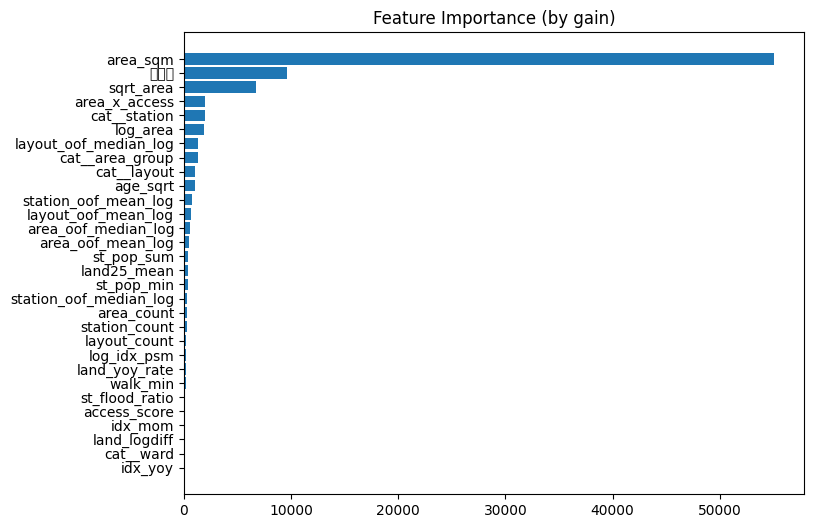

In [ ]:
# ===== 可視化（Feature Importance）=====
importance = model_point.feature_importance(importance_type="gain")
feature_names = model_point.feature_name()
fi = pd.DataFrame({"feature": feature_names, "importance": importance}).sort_values("importance", ascending=False)
print(fi.head(30))

plt.figure(figsize=(8, 6))
plt.barh(fi["feature"], fi["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (by gain)")
plt.show()
